# 06 — Smallwood / UF² / PULSUS Finite-Pulse Validation

## Goal

Validate the finite-pulse RWA implementation in PULSUS against two
independent references:

1. the finite-Gaussian-pulse three-level V-system treatment of
   Smallwood, Autry, and Cundiff;
2. the UF² implementation of Rose and Krich.

The primary comparison will use temporally separated pulses so that the
PULSUS factorization into finite-pulse Liouvillian operators is within
its intended regime of validity.

Primary target:

\[
S_{\mathrm{Smallwood}}
\approx
S_{\mathrm{UF^2}}
\approx
S_{\mathrm{PULSUS,B}}.
\]

Here model B denotes finite-pulse propagation with RWA-selected
interactions while retaining molecular evolution during the pulse.

## Notebook plan

1. Record software versions and paths.
2. Define the Smallwood three-level V system.
3. Define Gaussian pulse parameters and Fourier conventions.
4. Reproduce the reference finite-pulse calculation.
5. Run the same model with UF².
6. Run the same model with PULSUS model B.
7. Compare spectra and compute quantitative errors.
8. Save publication-quality validation figures.
9. Optionally scan \(T/\sigma\) to examine the separated-pulse limit.

In [12]:
from pathlib import Path
import sys
import platform

import numpy as np
import scipy
import matplotlib.pyplot as plt

import ufss

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("UFSS:", getattr(ufss, "__version__", "version not exposed"))
print("UFSS path:", ufss.__file__)

Python: 3.11.4
Platform: macOS-26.6-arm64-arm-64bit
NumPy: 2.4.6
SciPy: 1.17.1
UFSS: version not exposed
UFSS path: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/.venv/lib/python3.11/site-packages/ufss/__init__.py


In [13]:
ROOT = Path.cwd()

# If Jupyter was launched from the repository root:
if (ROOT / "src").exists():
    REPO = ROOT
else:
    REPO = ROOT.parent

FIGDIR = REPO / "figures" / "06_external_validation"
FIGDIR.mkdir(parents=True, exist_ok=True)

DATADIR = REPO / "data"

print("Repository:", REPO)
print("Figure directory:", FIGDIR)

Repository: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy
Figure directory: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/06_external_validation


In [14]:
SRC = REPO / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import pulsus

print("PULSUS:", pulsus.__file__)

# UFSS Fourier-transform helpers used by Rose and Krich
ift = ufss.signals.SignalProcessing.ift1D
ft = ufss.signals.SignalProcessing.ft1D

PULSUS: /Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/src/pulsus/__init__.py


# 1. Reference system and conventions

Before performing any numerical comparison, all three calculations must
use identical:

- level energies;
- transition dipoles;
- dephasing / relaxation parameters;
- pulse carrier frequencies;
- pulse widths;
- pulse normalization;
- pulse delays;
- phase-matching pathway;
- Fourier-transform conventions;
- spectral grids.

No normalization or phase correction will be introduced until any
difference between the implementations is understood.

## 1. Smallwood / UF² benchmark model

We reproduce the three-level V system used by Smallwood et al. and
implemented independently by Rose and Krich for the UF² validation.

Dimensionless units are chosen such that

\[
\omega_0 = 1,
\qquad
\sigma = \omega_0^{-1} = 1.
\]

In the rotating frame, the Hamiltonian is

\[
H =
\begin{pmatrix}
0 & 0 & 0 \\
0 & -1/2 & 0 \\
0 & 0 & +1/2
\end{pmatrix}.
\]

The optical dephasing rate is

\[
\gamma_{\mathrm{deph}} = 0.2,
\]

and the population / zero-quantum decay rate is

\[
\gamma_{\mathrm{decay}} = 0.1.
\]

Both ground-to-excited transition dipoles have unit magnitude.

In [15]:
# Smallwood / UF² benchmark parameters

sigma = 1.0

def g(t, sigma):
    return (
        1.0 / (np.sqrt(2 * np.pi) * sigma)
        * np.exp(-t**2 / (2 * sigma**2))
    )

def G(w, sigma):
    return np.exp(-w**2 * sigma**2 / 2)

def beta(sigma):
    return 1.0 / sigma


gamma_dephasing = 0.2 * beta(sigma)
gamma_decay = 0.1 * beta(sigma)

# Three-state V system in the rotating frame
H = np.diag([0.0, -0.5, +0.5])

print("H =")
print(H)
print()
print("sigma =", sigma)
print("beta =", beta(sigma))
print("gamma_dephasing =", gamma_dephasing)
print("gamma_decay =", gamma_decay)
print("intensity FWHM =", 2 * np.sqrt(np.log(2)) * sigma)

H =
[[ 0.   0.   0. ]
 [ 0.  -0.5  0. ]
 [ 0.   0.   0.5]]

sigma = 1.0
beta = 1.0
gamma_dephasing = 0.2
gamma_decay = 0.1
intensity FWHM = 1.6651092223153954


## 2. UF² implementation of the Smallwood benchmark

The UF² benchmark follows the implementation supplied by Rose and
Krich in `Smallwood2017Comparison.ipynb`.

The Smallwood analytical solution includes only the standard
time-ordered rephasing diagrams. Therefore, even for the published
\(T=0\) comparison, UF² is restricted to those same diagrams rather
than including all additional diagrams that become allowed by pulse
overlap.

We first reproduce the published \(T=0\) benchmark. We then use the
same model and diagrams at a well-separated waiting time
\(T=2\pi\sigma\), where comparison with the separated-pulse PULSUS
finite-width expression is appropriate.

In [16]:
# UFSS uses C-order / row-stacked vectorization for this benchmark.

n0 = np.zeros((3, 3))
n1 = np.zeros((3, 3))
n2 = np.zeros((3, 3))

n0[0, 0] = 1.0
n1[1, 1] = 1.0
n2[2, 2] = 1.0

c = 0.0  # optical gap rotated away

H_ufss = (
    0.0 * n0
    + (c - 0.5) * n1
    + (c + 0.5) * n2
)

II = np.eye(3)

L_closed_ufss = (
    -1j * np.kron(H_ufss, II.T)
    + 1j * np.kron(II, H_ufss.T)
)

R_ufss = np.zeros_like(L_closed_ufss)

R_ufss[1, 1] = gamma_dephasing
R_ufss[2, 2] = gamma_dephasing
R_ufss[3, 3] = gamma_dephasing
R_ufss[4, 4] = gamma_decay
R_ufss[5, 5] = gamma_decay
R_ufss[6, 6] = gamma_dephasing
R_ufss[7, 7] = gamma_decay
R_ufss[8, 8] = gamma_decay

L0_ufss = L_closed_ufss - R_ufss

print("H_ufss =")
print(H_ufss)

print("\nDiagonal of L0_ufss:")
print(np.diag(L0_ufss))

H_ufss =
[[ 0.   0.   0. ]
 [ 0.  -0.5  0. ]
 [ 0.   0.   0.5]]

Diagonal of L0_ufss:
[ 0. +0.j  -0.2-0.5j -0.2+0.5j -0.2+0.5j -0.1+0.j  -0.1+1.j  -0.2-0.5j
 -0.1-1.j  -0.1+0.j ]


In [17]:
mu_ag = np.zeros((3, 3))
mu_ag[1, 0] = 1.0
mu_ga = mu_ag.T

mu_bg = np.zeros((3, 3))
mu_bg[2, 0] = 1.0
mu_gb = mu_bg.T

mu_ufss = mu_ag + mu_ga + mu_bg + mu_gb

# Raising part used by UFSS to enforce the RWA
mu_up_ufss = mu_ag + mu_bg

print("mu_up_ufss =")
print(mu_up_ufss)

mu_up_ufss =
[[0. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [18]:
UFSSDIR = REPO / "data" / "06_external_validation" / "ufss_smallwood"
UFSSDIR.mkdir(parents=True, exist_ok=True)

print(UFSSDIR)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/data/06_external_validation/ufss_smallwood


In [19]:
manL = ufss.HLG.ManualL(
    L0_ufss,
    mu_up_ufss,
    savedir=str(UFSSDIR),
    output="uf2",
)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/data/06_external_validation/ufss_smallwood/open
/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/data/06_external_validation/ufss_smallwood/open/L.npz


In [20]:
M = 25
Delta = 6.0 * sigma

t_pulse = np.linspace(-Delta / 2, Delta / 2, num=M)
dt_pulse = t_pulse[1] - t_pulse[0]

ef = g(t_pulse, sigma)

print("M =", M)
print("Delta =", Delta)
print("dt =", dt_pulse)

M = 25
Delta = 6.0
dt = 0.25


In [22]:
# UF² rephasing 2D photon-echo engine

re = ufss.DensityMatrices(
    str(UFSSDIR / "open"),
    detection_type="complex_polarization",
)

# Delta-function local oscillator used in the original benchmark
lo_dt = 0.25
lo_t = np.arange(-5, 5.2, lo_dt)

lo = np.zeros(lo_t.size, dtype=float)
lo[lo.size // 2] = 1.0 / lo_dt

re.set_polarization_sequence(["x", "x", "x", "x"])

re.set_efields(
    [t_pulse, t_pulse, t_pulse, lo_t],
    [ef, ef, ef, lo],
    [0, 0, 0, 0],
    [(0, 1), (1, 0), (1, 0)],
)

re.gamma_res = 20
re.set_t(gamma_dephasing)

re.pulse_times = [0, 0, 0]

tau = re.t.copy()

# Published Rose/Krich benchmark first: T = 0
T = np.array([0.0])

re.set_pulse_delays([tau, T])

print("tau points:", tau.size)
print("tau min/max:", tau[0], tau[-1])
print("dtau:", tau[1] - tau[0])
print("T:", T)
print("detection-frequency points:", re.w.size)

tau points: 801
tau min/max: -100.0 100.0
dtau: 0.25
T: [0.]
detection-frequency points: 801


In [23]:
# Generate the standard time-ordered rephasing diagrams
# used in the Smallwood analytical comparison.

da = ufss.DiagramGenerator()

da.efield_times = [
    t_pulse,
    t_pulse,
    t_pulse,
    lo_t,
]

da.set_phase_discrimination([
    (0, 1),
    (1, 0),
    (1, 0),
])

# Artificially separate the pulses so that the generator returns
# only the conventional time-ordered diagrams.
time_ordered_diagrams = da.get_diagrams([0, 100, 200, 200])

print("Number of diagrams:", len(time_ordered_diagrams))
print()
for i, diagram in enumerate(time_ordered_diagrams, start=1):
    print(f"Diagram {i}:")
    print(diagram)

Number of diagrams: 3

Diagram 1:
(('Bu', 0), ('Ku', 1), ('Ku', 2))
Diagram 2:
(('Bu', 0), ('Ku', 1), ('Bd', 2))
Diagram 3:
(('Bu', 0), ('Bd', 1), ('Ku', 2))


In [24]:
# Calculate the Smallwood time-ordered UF² signal at T = 0

sig_uf2_T0 = re.calculate_diagrams_all_delays(
    time_ordered_diagrams
)

wtau, sig_uf2_T0_ft = ift(
    tau,
    sig_uf2_T0,
    zero_DC=False,
    axis=0,
)

print("time-domain shape:", sig_uf2_T0.shape)
print("frequency-domain shape:", sig_uf2_T0_ft.shape)
print("wtau points:", wtau.size)

print(
    "all finite:",
    np.all(np.isfinite(sig_uf2_T0_ft))
)

print(
    "max |signal|:",
    np.max(np.abs(sig_uf2_T0_ft))
)

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/.venv/lib/python3.11/site-packages/ufss/perturbative_calculations/UF2_open_core.py:636: UserWarning: Using L_mu for expectation values because H_mu is not available
  warnings.warn('Using L_mu for expectation values because H_mu is not available')


time-domain shape: (801, 1, 801)
frequency-domain shape: (801, 1, 801)
wtau points: 801
all finite: True
max |signal|: 0.8146318206374562


None


(<Figure size 640x480 with 1 Axes>, <Axes: >)

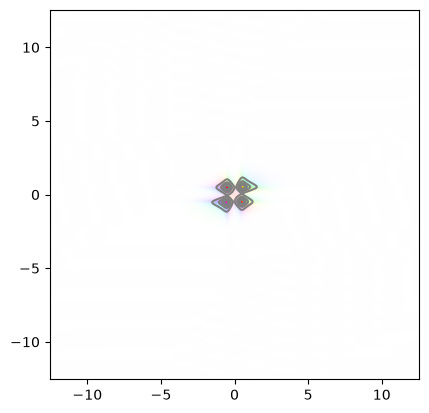

In [25]:
# Plot the published T = 0 UF² benchmark

ufss.signals.plot2D(
    re.w,
    wtau,
    -sig_uf2_T0_ft[:, 0, :].T,
    contour_levels=[0.2, 0.4, 0.6, 0.8],
    contour_colormap=None,
    contour_colors="gray",
    colorbar=False,
)

None


(-2.0, 2.0)

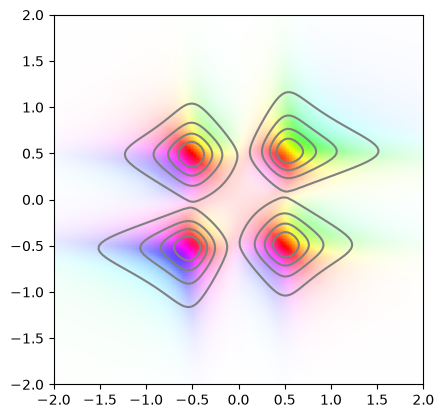

In [26]:
ufss.signals.plot2D(
    re.w,
    wtau,
    -sig_uf2_T0_ft[:, 0, :].T,
    contour_levels=[0.2, 0.4, 0.6, 0.8],
    contour_colormap=None,
    contour_colors="gray",
    colorbar=False,
)

plt.xlim(-2, 2)
plt.ylim(-2, 2)

In [27]:
from scipy.special import erf


def Pij(w, Wij):
    return 1j / (w - Wij)


def Da(wt, T, wtau, eta, Wjk, Whi, Wfg, mu, sigma):
    wt = wt[:, np.newaxis, np.newaxis]
    T = T[np.newaxis, :, np.newaxis]
    wtau = wtau[np.newaxis, np.newaxis, :]

    pre = 1j * mu[2] * mu[1] * mu[0] / (2 * np.pi)

    wt_terms = (
        Pij(wt, Wjk)
        * G(wt - eta[2] * c - Whi, sigma)
    )

    wtau_terms = (
        Pij(wtau, Wfg)
        * G(wtau - eta[0] * c, sigma)
        * G(wtau + eta[1] * c - Whi, sigma)
    )

    T_terms = np.exp(-1j * Whi * T)

    mixed = 0.5 * (
        1
        + erf(
            (
                T
                + 1j * sigma**2
                * (
                    wt
                    + wtau
                    - eta[2] * c
                    + eta[1] * c
                    - 2 * Whi
                )
            )
            / (2 * sigma)
        )
    )

    return pre * wt_terms * wtau_terms * T_terms * mixed


eta = [-1, 1, 1]
mu_path = [1, 1, 1]

# Convert UFSS Liouvillian eigenvalues to Smallwood's
# complex resonance-frequency convention.
eigvals = np.diag(L0_ufss) / (-1j)
W = eigvals.reshape((3, 3))

print("W =")
print(W)

W =
[[-0. -0.j   0.5-0.2j -0.5-0.2j]
 [-0.5-0.2j -0. -0.1j -1. -0.1j]
 [ 0.5-0.2j  1. -0.1j -0. -0.1j]]


In [28]:
wt = re.w
c = 0.0

analytical_T0 = -1j * (
    Da(wt + c, T, wtau - c, eta, W[1,0], W[1,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[1,0], W[1,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[2,0], W[2,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[2,0], W[2,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[2,0], W[0,0], W[0,1], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[2,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[1,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T, wtau - c, eta, W[1,0], W[0,0], W[0,1], mu_path, sigma)
)

print("analytical shape:", analytical_T0.shape)
print("all finite:", np.all(np.isfinite(analytical_T0)))
print("max |analytic|:", np.max(np.abs(analytical_T0)))

analytical shape: (801, 1, 801)
all finite: True
max |analytic|: 2.553412979050506


In [30]:
# Convert the current UFSS convention to the convention used
# in the Rose/Krich Smallwood benchmark.
S_uf2_T0_compare = -np.pi * sig_uf2_T0_ft[:, 0, :].T

S_smallwood_T0 = analytical_T0[:, 0, :]

error_T0 = (
    np.linalg.norm(S_uf2_T0_compare - S_smallwood_T0)
    / np.linalg.norm(S_smallwood_T0)
)

print("max |UF² comparison signal|:",
      np.max(np.abs(S_uf2_T0_compare)))

print("max |Smallwood analytic|:",
      np.max(np.abs(S_smallwood_T0)))

print(
    f"UF² vs Smallwood relative L2 error = "
    f"{100 * error_T0:.4f}%"
)

max |UF² comparison signal|: 2.55924134309511
max |Smallwood analytic|: 2.553412979050506
UF² vs Smallwood relative L2 error = 0.6994%


### Published UF² benchmark reproduced

Using the pulse discretization of Rose and Krich,

\[
\Delta = 6\sigma,\qquad
dt = 0.25\sigma,\qquad
M = 25,
\]

the present calculation gives

\[
\epsilon_{\mathrm{UF^2-Smallwood}}
=
\frac{
\|S_{\mathrm{UF^2}}-S_{\mathrm{Smallwood}}\|_2
}{
\|S_{\mathrm{Smallwood}}\|_2
}
=
0.6994\%.
\]

This reproduces the published UF² validation against the analytical
finite-pulse result of Smallwood et al. to better than 1%.

In [31]:
# Safely separated waiting time used in Smallwood Fig. 3(g)

T_sep = np.array([2 * np.pi * sigma])

re.set_pulse_delays([tau, T_sep])

sig_uf2_sep = re.calculate_diagrams_all_delays(
    time_ordered_diagrams
)

wtau_sep, sig_uf2_sep_ft = ift(
    tau,
    sig_uf2_sep,
    zero_DC=False,
    axis=0,
)

print("T/sigma =", T_sep[0] / sigma)
print("UF² shape:", sig_uf2_sep_ft.shape)
print("all finite:", np.all(np.isfinite(sig_uf2_sep_ft)))

T/sigma = 6.283185307179586
UF² shape: (801, 1, 801)
all finite: True


In [32]:
analytical_sep = -1j * (
    Da(wt + c, T_sep, wtau_sep - c, eta, W[1,0], W[1,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[1,0], W[1,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[2,0], W[2,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[2,0], W[2,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[2,0], W[0,0], W[0,1], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[2,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[1,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T_sep, wtau_sep - c, eta, W[1,0], W[0,0], W[0,1], mu_path, sigma)
)

S_uf2_sep_compare = -np.pi * sig_uf2_sep_ft[:, 0, :].T
S_smallwood_sep = analytical_sep[:, 0, :]

error_sep = (
    np.linalg.norm(S_uf2_sep_compare - S_smallwood_sep)
    / np.linalg.norm(S_smallwood_sep)
)

print("max |UF²|:", np.max(np.abs(S_uf2_sep_compare)))
print("max |Smallwood|:", np.max(np.abs(S_smallwood_sep)))
print(
    f"UF² vs Smallwood at T = 2πσ: "
    f"{100 * error_sep:.4f}%"
)

max |UF²|: 4.831205703858098
max |Smallwood|: 4.828409386790923
UF² vs Smallwood at T = 2πσ: 0.3430%


### Separated-pulse benchmark

At the waiting time used in Smallwood Fig. 3(g),

\[
T = 2\pi\sigma,
\]

the UF² calculation gives

\[
\epsilon_{\mathrm{UF^2-Smallwood}}
=
0.3430\%.
\]

Thus the numerical UF² calculation reproduces the analytical
finite-pulse result in the separated-pulse regime to substantially
better than 1%.

In [33]:
from pulsus.liouville import (
    hamiltonian_liouvillian,
    interaction_superoperator,
)

# ------------------------------------------------------------
# Smallwood V-system in PULSUS column-stacking convention
# ------------------------------------------------------------

H_pulsus = np.diag([
    0.0,
    -0.5,
    +0.5,
]).astype(complex)

# Hamiltonian Liouvillian:
# L_H rho = -i [H, rho]
L_H_pulsus = hamiltonian_liouvillian(
    H_pulsus,
    hbar=1.0,
)

# Phenomenological Smallwood damping.
#
# PULSUS column-stacked ordering:
#
#   0 -> rho00
#   1 -> rho10
#   2 -> rho20
#   3 -> rho01
#   4 -> rho11
#   5 -> rho21
#   6 -> rho02
#   7 -> rho12
#   8 -> rho22

R_pulsus = np.zeros((9, 9), dtype=complex)

# Optical coherences
for idx in [1, 2, 3, 6]:
    R_pulsus[idx, idx] = gamma_dephasing

# Excited populations and zero-quantum coherences
for idx in [4, 5, 7, 8]:
    R_pulsus[idx, idx] = gamma_decay

L_pulsus = L_H_pulsus - R_pulsus


# Initial ground state
rho0_pulsus = np.zeros((3, 3), dtype=complex)
rho0_pulsus[0, 0] = 1.0


# Raising and lowering parts of the transition dipole
mu_plus_pulsus = np.array([
    [0.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
], dtype=complex)

mu_minus_pulsus = mu_plus_pulsus.conj().T
mu_pulsus = mu_plus_pulsus + mu_minus_pulsus


# Corresponding PULSUS interaction superoperators
V_plus_pulsus = interaction_superoperator(
    mu_plus_pulsus,
    hbar=1.0,
)

V_minus_pulsus = interaction_superoperator(
    mu_minus_pulsus,
    hbar=1.0,
)


print("L shape:", L_pulsus.shape)
print("rho0 trace:", np.trace(rho0_pulsus))
print("mu+ =")
print(mu_plus_pulsus)

print()
print("Liouvillian diagonal:")
print(np.diag(L_pulsus))

L shape: (9, 9)
rho0 trace: (1+0j)
mu+ =
[[0.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j 0.+0.j]]

Liouvillian diagonal:
[ 0. -0.j  -0.2+0.5j -0.2-0.5j -0.2-0.5j -0.1-0.j  -0.1-1.j  -0.2+0.5j
 -0.1+1.j  -0.1-0.j ]


In [34]:
# Strongest point of the separated Smallwood analytical spectrum

peak_idx = np.unravel_index(
    np.argmax(np.abs(S_smallwood_sep)),
    S_smallwood_sep.shape,
)

i_wt, i_wtau = peak_idx

wt_peak = wt[i_wt]
wtau_peak = wtau_sep[i_wtau]

print("peak indices:", peak_idx)
print("omega_t =", wt_peak)
print("omega_tau =", wtau_peak)
print("Smallwood signal =", S_smallwood_sep[peak_idx])
print("abs =", np.abs(S_smallwood_sep[peak_idx]))

E0_smallwood = 2.0 / (
    np.sqrt(2.0 * np.pi) * sigma
)

print("PULSUS E0 =", E0_smallwood)

peak indices: (np.int64(384), np.int64(384))
omega_t = -0.5020272904612902
omega_tau = -0.5020272904612902
Smallwood signal = (4.4487558825400875-1.876728084730353j)
abs = 4.828409386790923
PULSUS E0 = 0.7978845608028654


In [35]:
from pulsus import finite_pulse_rwa_response


# Smallwood/UFSS -> PULSUS frequency convention
omega1_peak = -wtau_peak
omega3_peak = wt_peak

# The physical linewidths are already contained in L_pulsus,
# so eta is only a tiny numerical 0+.
eta_pulsus = 1.0e-12


S_pulsus_peak = finite_pulse_rwa_response(
    L_super=L_pulsus,
    V_plus=V_plus_pulsus,
    V_minus=V_minus_pulsus,
    observable=mu_pulsus,
    rho0=rho0_pulsus,
    omega1=omega1_peak,
    omega3=omega3_peak,
    T=T_sep[0],
    eta=eta_pulsus,
    omega_L1=0.0,
    omega_L2=0.0,
    omega_L3=0.0,
    sigma1=sigma,
    sigma2=sigma,
    sigma3=sigma,
    pathway="R",
    E01=E0_smallwood,
    E02=E0_smallwood,
    E03=E0_smallwood,
)

S_smallwood_peak = S_smallwood_sep[peak_idx]

print("omega1 PULSUS =", omega1_peak)
print("omega3 PULSUS =", omega3_peak)
print()
print("PULSUS =", S_pulsus_peak)
print("Smallwood =", S_smallwood_peak)
print()
print("|PULSUS| =", np.abs(S_pulsus_peak))
print("|Smallwood| =", np.abs(S_smallwood_peak))
print()
print("PULSUS / Smallwood =", S_pulsus_peak / S_smallwood_peak)

omega1 PULSUS = 0.5020272904612902
omega3 PULSUS = -0.5020272904612902

PULSUS = (1.3322676295501878e-15-29.2730877443503j)
Smallwood = (4.4487558825400875-1.876728084730353j)

|PULSUS| = 29.2730877443503
|Smallwood| = 4.828409386790923

PULSUS / Smallwood = (2.3564689223305533-5.5859743697218605j)


In [36]:
def pulsus_peak_test(omega1, omega3):
    return finite_pulse_rwa_response(
        L_super=L_pulsus,
        V_plus=V_plus_pulsus,
        V_minus=V_minus_pulsus,
        observable=mu_pulsus,
        rho0=rho0_pulsus,
        omega1=omega1,
        omega3=omega3,
        T=T_sep[0],
        eta=eta_pulsus,
        omega_L1=0.0,
        omega_L2=0.0,
        omega_L3=0.0,
        sigma1=sigma,
        sigma2=sigma,
        sigma3=sigma,
        pathway="R",
        E01=E0_smallwood,
        E02=E0_smallwood,
        E03=E0_smallwood,
    )


tests = {
    "(-wtau, +wt)": (-wtau_peak, +wt_peak),
    "(+wtau, +wt)": (+wtau_peak, +wt_peak),
    "(-wtau, -wt)": (-wtau_peak, -wt_peak),
    "(+wtau, -wt)": (+wtau_peak, -wt_peak),
}

print("Smallwood reference:")
print(S_smallwood_peak)
print()

for label, (w1, w3) in tests.items():
    S = pulsus_peak_test(w1, w3)

    print(label)
    print("  omega1 =", w1)
    print("  omega3 =", w3)
    print("  PULSUS =", S)
    print("  |PULSUS| =", abs(S))
    print("  ratio =", S / S_smallwood_peak)
    print()

Smallwood reference:
(4.4487558825400875-1.876728084730353j)

(-wtau, +wt)
  omega1 = 0.5020272904612902
  omega3 = -0.5020272904612902
  PULSUS = (1.3322676295501878e-15-29.2730877443503j)
  |PULSUS| = 29.2730877443503
  ratio = (2.3564689223305533-5.5859743697218605j)

(+wtau, +wt)
  omega1 = -0.5020272904612902
  omega3 = -0.5020272904612902
  PULSUS = (-11.791751252455597-27.95214250762501j)
  |PULSUS| = 30.337562004326667
  ratio = (-2.2252035739411803e-06-6.283137897817699j)

(-wtau, -wt)
  omega1 = 0.5020272904612902
  omega3 = 0.5020272904612902
  PULSUS = (11.791751252455597-27.95214250762501j)
  |PULSUS| = 30.337562004326667
  ratio = (4.5002692081074-4.384677741585848j)

(+wtau, -wt)
  omega1 = -0.5020272904612902
  omega3 = 0.5020272904612902
  PULSUS = (-1.3322676295501878e-15-29.2730877443503j)
  |PULSUS| = 29.2730877443503
  ratio = (2.3564689223305524-5.5859743697218605j)



In [37]:
# Check whether the PULSUS / Smallwood conversion is a global constant

test_indices = [
    (384, 384),   # strongest peak
    (416, 384),
    (384, 416),
    (416, 416),
    (400, 400),
]

target_factor = -1j * 2 * np.pi

for idx in test_indices:
    i_wt, i_wtau = idx

    w3 = wt[i_wt]
    w1 = wtau_sep[i_wtau]

    S_p = pulsus_peak_test(w1, w3)
    S_s = S_smallwood_sep[idx]

    print("index:", idx)
    print("  wtau, wt =", w1, w3)
    print("  Smallwood =", S_s)
    print("  PULSUS    =", S_p)

    if abs(S_s) > 1e-12:
        ratio = S_p / S_s
        print("  ratio =", ratio)
        print("  ratio / (-i 2pi) =", ratio / target_factor)

    print()

index: (384, 384)
  wtau, wt = -0.5020272904612902 -0.5020272904612902
  Smallwood = (4.4487558825400875-1.876728084730353j)
  PULSUS    = (-11.791751252455597-27.95214250762501j)
  ratio = (-2.2252035739411803e-06-6.283137897817699j)
  ratio / (-i 2pi) = (0.9999924545657068-3.541521481784907e-07j)

index: (416, 384)
  wtau, wt = -0.5020272904612902 0.5020272904612902
  Smallwood = (4.658927890540271+1.1381943269098256e-16j)
  PULSUS    = (-1.3322676295501878e-15-29.2730877443503j)
  ratio = (-4.39461754697918e-16-6.283224044696612j)
  ratio / (-i 2pi) = (1.0000061652673178-6.994251056001162e-17j)

index: (384, 416)
  wtau, wt = 0.5020272904612902 -0.5020272904612902
  Smallwood = (4.658927890540271-1.1268722864789595e-16j)
  PULSUS    = (1.3322676295501878e-15-29.2730877443503j)
  ratio = (4.3793481720625405e-16-6.283224044696612j)
  ratio / (-i 2pi) = (1.0000061652673178+6.969949091042095e-17j)

index: (416, 416)
  wtau, wt = 0.5020272904612902 0.5020272904612902
  Smallwood = (4.448

In [38]:
import importlib
import pulsus
import pulsus.spectra

importlib.reload(pulsus.spectra)
importlib.reload(pulsus)

print("finite_pulse_rwa_spectrum available:",
      hasattr(pulsus, "finite_pulse_rwa_spectrum"))

finite_pulse_rwa_spectrum available: True


In [39]:
# PULSUS system object for the Smallwood benchmark.
#
# Smallwood's phenomenological damping is not trace-conserving,
# so we construct the Hilbert-space objects normally and then
# replace the field-free Liouvillian by the benchmark L_pulsus.

smallwood_system = pulsus.SpectroscopySystem(
    H=H_pulsus,
    dipole=mu_pulsus,
    collapse_ops=[],
    rho0=rho0_pulsus,
    hbar=1.0,
    dipole_plus=mu_plus_pulsus,
    dipole_minus=mu_minus_pulsus,
)

smallwood_system.L = L_pulsus.copy()

smallwood_pulse = pulsus.GaussianPulse(
    omega_L=0.0,
    sigma=sigma,
    E0=E0_smallwood,
)

print("L matches benchmark:",
      np.allclose(smallwood_system.L, L_pulsus))

print("RWA operators available:",
      smallwood_system.V_plus is not None
      and smallwood_system.V_minus is not None)

L matches benchmark: True
RWA operators available: True


In [40]:
import time

t0 = time.perf_counter()

S_pulsus_sep_raw = pulsus.finite_pulse_rwa_spectrum(
    system=smallwood_system,
    pulse1=smallwood_pulse,
    pulse2=smallwood_pulse,
    pulse3=smallwood_pulse,
    omega1=wtau_sep,
    omega3=wt,
    T=T_sep[0],
    eta=eta_pulsus,
    pathway="R",
)

elapsed = time.perf_counter() - t0

# Convert PULSUS response convention to the
# Smallwood / UFSS convention established above:
#
# S_PULSUS = -i 2π S_Smallwood

S_pulsus_sep = (
    1j / (2 * np.pi)
) * S_pulsus_sep_raw

error_pulsus_smallwood = (
    np.linalg.norm(
        S_pulsus_sep - S_smallwood_sep
    )
    / np.linalg.norm(S_smallwood_sep)
)

error_pulsus_uf2 = (
    np.linalg.norm(
        S_pulsus_sep - S_uf2_sep_compare
    )
    / np.linalg.norm(S_uf2_sep_compare)
)

print("PULSUS shape:", S_pulsus_sep.shape)
print("all finite:", np.all(np.isfinite(S_pulsus_sep)))
print(f"runtime: {elapsed:.3f} s")
print()

print("max |PULSUS|:",
      np.max(np.abs(S_pulsus_sep)))
print("max |Smallwood|:",
      np.max(np.abs(S_smallwood_sep)))
print("max |UF²|:",
      np.max(np.abs(S_uf2_sep_compare)))
print()

print(
    "PULSUS vs Smallwood relative L2 error = "
    f"{100 * error_pulsus_smallwood:.6f}%"
)

print(
    "PULSUS vs UF² relative L2 error = "
    f"{100 * error_pulsus_uf2:.6f}%"
)

PULSUS shape: (801, 801)
all finite: True
runtime: 0.073 s

max |PULSUS|: 4.828372954345458
max |Smallwood|: 4.828409386790923
max |UF²|: 4.831205703858098

PULSUS vs Smallwood relative L2 error = 0.000733%
PULSUS vs UF² relative L2 error = 0.343027%


/var/folders/48/7yf2h_qd2hnfgnx8vt9t3b_h0000gn/T/ipykernel_83456/3432387855.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


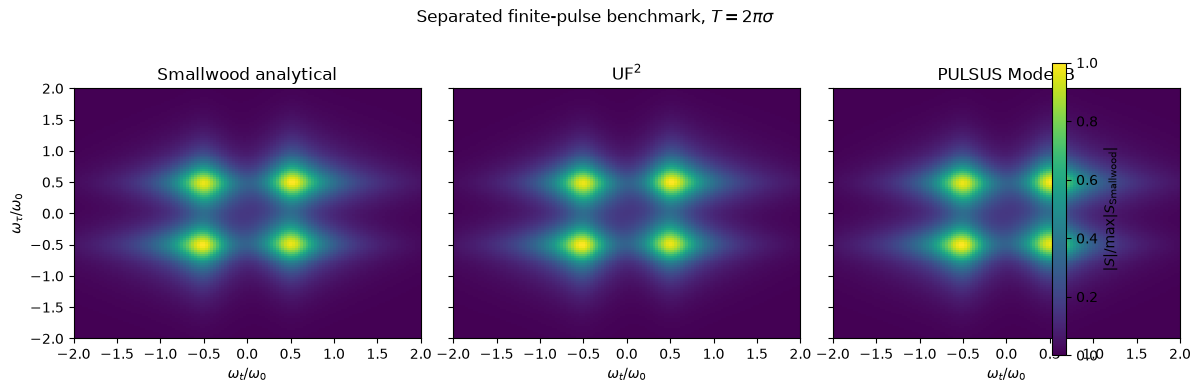

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/06_external_validation/smallwood_uf2_pulsus_T2pisigma.pdf


In [41]:
# Three-way external validation at T = 2πσ
# Common normalization to the analytical Smallwood maximum.

scale = np.max(np.abs(S_smallwood_sep))

datasets = [
    (
        "Smallwood analytical",
        np.abs(S_smallwood_sep) / scale,
    ),
    (
        r"UF$^2$",
        np.abs(S_uf2_sep_compare) / scale,
    ),
    (
        "PULSUS Model B",
        np.abs(S_pulsus_sep) / scale,
    ),
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(12.0, 3.8),
    sharex=True,
    sharey=True,
)

for ax, (title, Z) in zip(axes, datasets):

    mesh = ax.pcolormesh(
        wt,
        wtau_sep,
        Z.T,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    ax.set_xlabel(r"$\omega_t/\omega_0$")
    ax.set_title(title)

axes[0].set_ylabel(r"$\omega_\tau/\omega_0$")

cbar = fig.colorbar(
    mesh,
    ax=axes,
    pad=0.02,
    fraction=0.025,
)

cbar.set_label(
    r"$|S|/\max|S_{\mathrm{Smallwood}}|$"
)

fig.suptitle(
    r"Separated finite-pulse benchmark, "
    r"$T=2\pi\sigma$",
    y=1.02,
)

fig.tight_layout()

comparison_path = (
    FIGDIR
    / "smallwood_uf2_pulsus_T2pisigma.pdf"
)

fig.savefig(
    comparison_path,
    bbox_inches="tight",
)

plt.show()

print(comparison_path)

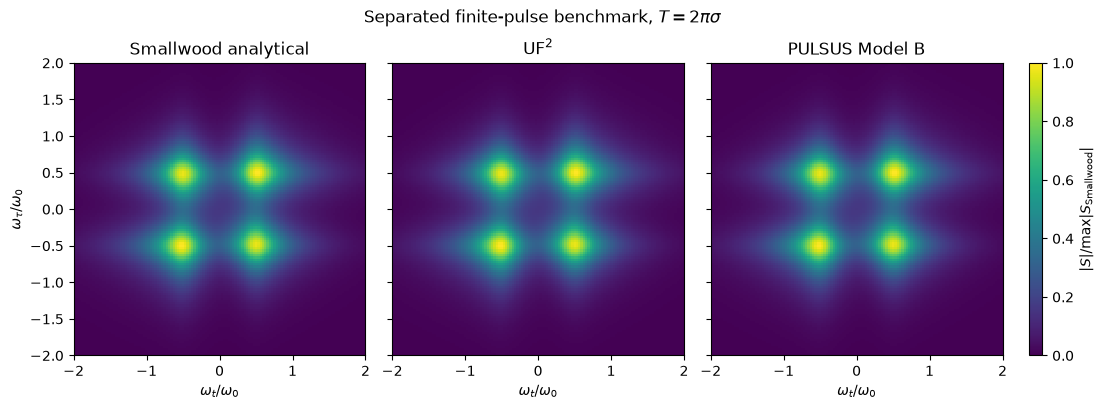

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/06_external_validation/smallwood_uf2_pulsus_T2pisigma.pdf


In [42]:
# Three-way external validation at T = 2πσ
# Common normalization to the analytical Smallwood maximum.

scale = np.max(np.abs(S_smallwood_sep))

datasets = [
    (
        "Smallwood analytical",
        np.abs(S_smallwood_sep) / scale,
    ),
    (
        r"UF$^2$",
        np.abs(S_uf2_sep_compare) / scale,
    ),
    (
        "PULSUS Model B",
        np.abs(S_pulsus_sep) / scale,
    ),
]

fig = plt.figure(
    figsize=(12.5, 3.8),
)

gs = fig.add_gridspec(
    1,
    4,
    width_ratios=[1, 1, 1, 0.045],
    wspace=0.12,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]

cax = fig.add_subplot(gs[0, 3])

for i, (ax, (title, Z)) in enumerate(
    zip(axes, datasets)
):

    mesh = ax.pcolormesh(
        wt,
        wtau_sep,
        Z.T,
        shading="auto",
        vmin=0.0,
        vmax=1.0,
        cmap="viridis",
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    ax.set_xlabel(r"$\omega_t/\omega_0$")
    ax.set_title(title)

    if i > 0:
        ax.set_yticklabels([])

axes[0].set_ylabel(
    r"$\omega_\tau/\omega_0$"
)

cbar = fig.colorbar(
    mesh,
    cax=cax,
)

cbar.set_label(
    r"$|S|/\max|S_{\mathrm{Smallwood}}|$"
)

fig.suptitle(
    r"Separated finite-pulse benchmark, "
    r"$T=2\pi\sigma$",
    y=1.02,
)

comparison_path = (
    FIGDIR
    / "smallwood_uf2_pulsus_T2pisigma.pdf"
)

fig.savefig(
    comparison_path,
    bbox_inches="tight",
)

plt.show()

print(comparison_path)

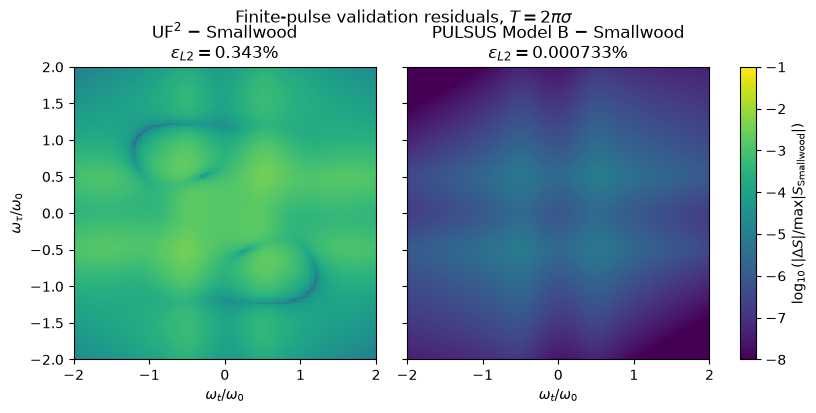

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/06_external_validation/smallwood_uf2_pulsus_residuals_T2pisigma.pdf


In [43]:
# Difference maps relative to the Smallwood analytical result

scale = np.max(np.abs(S_smallwood_sep))

diff_uf2 = (
    np.abs(S_uf2_sep_compare - S_smallwood_sep)
    / scale
)

diff_pulsus = (
    np.abs(S_pulsus_sep - S_smallwood_sep)
    / scale
)

# Avoid log10(0)
floor = 1e-10

log_diff_uf2 = np.log10(
    np.maximum(diff_uf2, floor)
)

log_diff_pulsus = np.log10(
    np.maximum(diff_pulsus, floor)
)

fig = plt.figure(
    figsize=(8.8, 3.8),
)

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1, 1, 0.05],
    wspace=0.15,
)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
]

cax = fig.add_subplot(gs[0, 2])

datasets = [
    (
        rf"UF$^2$ $-$ Smallwood"
        "\n"
        rf"$\epsilon_{{L2}}={100*error_sep:.3f}\%$",
        log_diff_uf2,
    ),
    (
        "PULSUS Model B $-$ Smallwood"
        "\n"
        rf"$\epsilon_{{L2}}={100*error_pulsus_smallwood:.6f}\%$",
        log_diff_pulsus,
    ),
]

for i, (ax, (title, Z)) in enumerate(
    zip(axes, datasets)
):

    mesh = ax.pcolormesh(
        wt,
        wtau_sep,
        Z.T,
        shading="auto",
        cmap="viridis",
        vmin=-8,
        vmax=-1,
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    ax.set_xlabel(r"$\omega_t/\omega_0$")
    ax.set_title(title)

    if i > 0:
        ax.set_yticklabels([])

axes[0].set_ylabel(
    r"$\omega_\tau/\omega_0$"
)

cbar = fig.colorbar(
    mesh,
    cax=cax,
)

cbar.set_label(
    r"$\log_{10}\left("
    r"|\Delta S|/"
    r"\max|S_{\mathrm{Smallwood}}|"
    r"\right)$"
)

fig.suptitle(
    r"Finite-pulse validation residuals, "
    r"$T=2\pi\sigma$",
    y=1.03,
)

difference_path = (
    FIGDIR
    / "smallwood_uf2_pulsus_residuals_T2pisigma.pdf"
)

fig.savefig(
    difference_path,
    bbox_inches="tight",
)

plt.show()

print(difference_path)

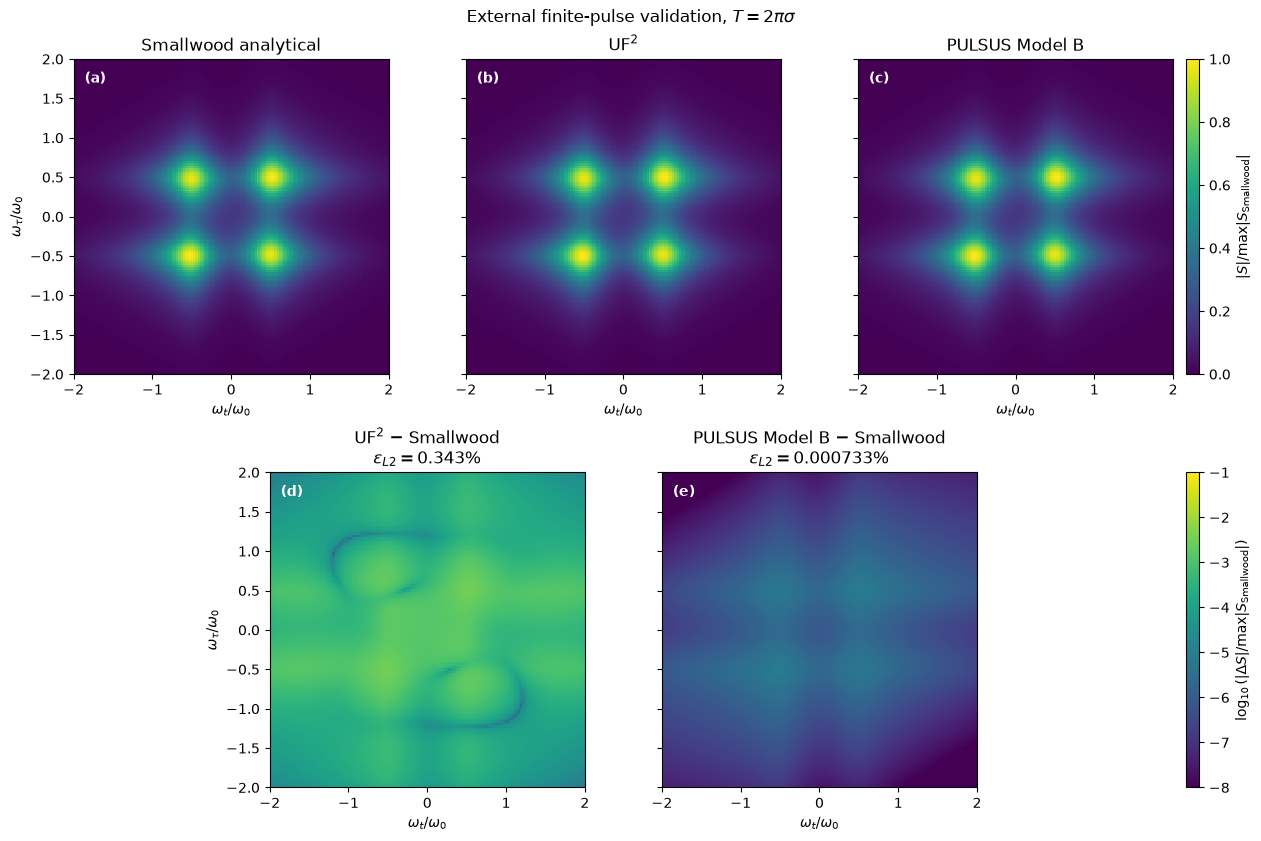

/Users/alfonsocastillogonzalez/Desktop/Research/Spectroscopy_proyect/GitHub/Direct-Frequency-Domain-Nonlinear-Spectroscopy/figures/06_external_validation/Figure02_external_validation_draft.pdf


In [46]:
# Figure 2 draft: external finite-pulse validation
# Inverted-pyramid layout with five square panels

scale = np.max(np.abs(S_smallwood_sep))

spectra = [
    ("Smallwood analytical", np.abs(S_smallwood_sep) / scale),
    (r"UF$^2$", np.abs(S_uf2_sep_compare) / scale),
    ("PULSUS Model B", np.abs(S_pulsus_sep) / scale),
]

floor = 1e-10

residuals = [
    (
        rf"UF$^2$ $-$ Smallwood"
        "\n"
        rf"$\epsilon_{{L2}}={100*error_sep:.3f}\%$",
        np.log10(
            np.maximum(
                np.abs(
                    S_uf2_sep_compare
                    - S_smallwood_sep
                ) / scale,
                floor,
            )
        ),
    ),
    (
        "PULSUS Model B $-$ Smallwood"
        "\n"
        rf"$\epsilon_{{L2}}="
        rf"{100*error_pulsus_smallwood:.6f}\%$",
        np.log10(
            np.maximum(
                np.abs(
                    S_pulsus_sep
                    - S_smallwood_sep
                ) / scale,
                floor,
            )
        ),
    ),
]


fig = plt.figure(
    figsize=(12.5, 8.3),
    layout="constrained",
)

# Six equal-width plotting columns plus one narrow
# colorbar column.
#
# Top:
#   aa bb cc |
#
# Bottom:
#    dd ee   |
#
# so the lower row is centered beneath the upper row.

gs = fig.add_gridspec(
    2,
    7,
    width_ratios=[
        1, 1,
        1, 1,
        1, 1,
        0.10,
    ],
    height_ratios=[1, 1],
)


# ============================================================
# Top row: three square spectra
# ============================================================

axes_top = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
]

cax_top = fig.add_subplot(
    gs[0, 6]
)

for i, (ax, (title, Z)) in enumerate(
    zip(axes_top, spectra)
):

    mesh_top = ax.pcolormesh(
        wt,
        wtau_sep,
        Z.T,
        shading="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    # Force a square plotting region
    ax.set_box_aspect(1)

    ax.set_xlabel(
        r"$\omega_t/\omega_0$"
    )

    ax.set_title(title)

    ax.text(
        0.035,
        0.96,
        f"({chr(ord('a') + i)})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
        color="white",
    )

    if i > 0:
        ax.set_yticklabels([])

axes_top[0].set_ylabel(
    r"$\omega_\tau/\omega_0$"
)

cbar_top = fig.colorbar(
    mesh_top,
    cax=cax_top,
)

cbar_top.set_label(
    r"$|S|/"
    r"\max|S_{\mathrm{Smallwood}}|$"
)


# ============================================================
# Bottom row: two centered square residual panels
# ============================================================

axes_bottom = [
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

cax_bottom = fig.add_subplot(
    gs[1, 6]
)

for i, (ax, (title, Z)) in enumerate(
    zip(axes_bottom, residuals)
):

    mesh_bottom = ax.pcolormesh(
        wt,
        wtau_sep,
        Z.T,
        shading="auto",
        cmap="viridis",
        vmin=-8,
        vmax=-1,
    )

    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)

    # Same physical size/aspect as the top panels
    ax.set_box_aspect(1)

    ax.set_xlabel(
        r"$\omega_t/\omega_0$"
    )

    ax.set_title(title)

    ax.text(
        0.035,
        0.96,
        f"({chr(ord('d') + i)})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontweight="bold",
        color="white",
    )

    if i > 0:
        ax.set_yticklabels([])

axes_bottom[0].set_ylabel(
    r"$\omega_\tau/\omega_0$"
)

cbar_bottom = fig.colorbar(
    mesh_bottom,
    cax=cax_bottom,
)

cbar_bottom.set_label(
    r"$\log_{10}\left("
    r"|\Delta S|/"
    r"\max|S_{\mathrm{Smallwood}}|"
    r"\right)$"
)


fig.suptitle(
    r"External finite-pulse validation, "
    r"$T=2\pi\sigma$",
)


figure2_path = (
    FIGDIR
    / "Figure02_external_validation_draft.pdf"
)

fig.savefig(
    figure2_path,
    bbox_inches="tight",
)

plt.show()

print(figure2_path)

In [45]:
# Check whether the tiny PULSUS-Smallwood residual
# decreases further as the pulses become more separated.

T_check = np.array([8.0 * sigma])

analytical_T8 = -1j * (
    Da(wt + c, T_check, wtau_sep - c, eta, W[1,0], W[1,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[1,0], W[1,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[2,0], W[2,2], W[0,2], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[2,0], W[2,1], W[0,1], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[2,0], W[0,0], W[0,1], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[2,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[1,0], W[0,0], W[0,2], mu_path, sigma)
    + Da(wt + c, T_check, wtau_sep - c, eta, W[1,0], W[0,0], W[0,1], mu_path, sigma)
)

S_smallwood_T8 = analytical_T8[:, 0, :]

S_pulsus_T8_raw = pulsus.finite_pulse_rwa_spectrum(
    system=smallwood_system,
    pulse1=smallwood_pulse,
    pulse2=smallwood_pulse,
    pulse3=smallwood_pulse,
    omega1=wtau_sep,
    omega3=wt,
    T=T_check[0],
    eta=eta_pulsus,
    pathway="R",
)

S_pulsus_T8 = (
    1j / (2 * np.pi)
) * S_pulsus_T8_raw

error_T8 = (
    np.linalg.norm(S_pulsus_T8 - S_smallwood_T8)
    / np.linalg.norm(S_smallwood_T8)
)

print(f"T/sigma = {T_check[0] / sigma:.1f}")
print(
    "PULSUS vs Smallwood relative L2 error = "
    f"{100 * error_T8:.9f}%"
)

T/sigma = 8.0
PULSUS vs Smallwood relative L2 error = 0.000001702%


# 4. Validation summary

The three-level V-system benchmark provides an external validation of
the finite-pulse RWA implementation in PULSUS.

First, the published UF² comparison against the analytical finite-pulse
solution of Smallwood et al. was reproduced using the pulse
discretization

\[
\Delta = 6\sigma,\qquad
dt = 0.25\sigma,\qquad
M = 25.
\]

At \(T=0\),

\[
\epsilon_{\mathrm{UF^2-Smallwood}}
=
0.6994\%.
\]

For the separated-pulse benchmark at

\[
T=2\pi\sigma,
\]

the corresponding error decreases to

\[
\epsilon_{\mathrm{UF^2-Smallwood}}
=
0.3430\%.
\]

Using the same physical three-level model and Gaussian pulses, the
finite-pulse RWA response calculated with PULSUS gives

\[
\epsilon_{\mathrm{PULSUS-Smallwood}}
=
0.000733\%.
\]

The PULSUS and Smallwood/UF² response conventions differ by the global
factor

\[
S_{\mathrm{PULSUS}}
=
-i\,2\pi\,S_{\mathrm{Smallwood}},
\]

which follows from their different Fourier and polarization
conventions and is not obtained by fitting the spectra.

As an additional separation check, increasing the waiting time to

\[
T=8\sigma
\]

reduces the PULSUS--Smallwood discrepancy to

\[
1.702\times10^{-6}\%.
\]

The remaining difference at \(T=2\pi\sigma\) is therefore consistent
with the small finite temporal-ordering correction that disappears in
the well-separated-pulse limit.

These results validate PULSUS Model B,

\[
\text{finite pulse}
+
\text{molecular RWA}
+
\text{Liouvillian evolution during the pulse},
\]

against both an analytical finite-pulse solution and an independent
numerical implementation.